In [7]:
from datetime import datetime, timedelta
import pandas as pd
import glob
import numpy as np

import numpy as np
import glob, re
import pandas as pd
import requests
import os
import warnings
warnings.filterwarnings("ignore")
from scipy.stats import mode
from matplotlib import pyplot as plt
import numpy as np
import glob
import healpy as hp
import pandas as pd

from astropy.coordinates import SkyCoord, AltAz
from astropy.table import Table
from astropy.utils.data import get_readable_fileobj
from astropy import units as u
from astropy.time import Time
from astropy.coordinates import get_sun

from astroplan import FixedTarget, Observer, Constraint, is_observable, min_best_rescale,AirmassConstraint

import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord, get_body
import astropy.units as u
from astropy.time import Time

def generate_time_list(start_time_str, increment_minutes, total_steps):
    """
    Generates a list of timestamps starting from a given time.
    """
    start_time = datetime.strptime(start_time_str, "%Y-%m-%d %H:%M:%S")
    time_list = []
    
    for i in range(total_steps):
        # Add the increment multiplied by the current step
        current_time = start_time + timedelta(minutes=increment_minutes * i)
        time_list.append(current_time.strftime("%Y-%m-%d %H:%M:%S"))
        
    return time_list

# Generate 17 steps (8 hours) starting at 2026-04-21 23:00:00

timestamps = generate_time_list('2026-05-01 23:00:00', 30, 20)



In [2]:
import pandas as pd
import glob
import numpy as np

import numpy as np
import glob, re
import pandas as pd
import requests
import os
import warnings
warnings.filterwarnings("ignore")
from scipy.stats import mode
from matplotlib import pyplot as plt
import numpy as np
import glob
import healpy as hp
import pandas as pd

from astropy.coordinates import SkyCoord, AltAz
from astropy.table import Table
from astropy.utils.data import get_readable_fileobj
from astropy import units as u
from astropy.time import Time
from astropy.coordinates import get_sun

from astroplan import FixedTarget, Observer, Constraint, is_observable, min_best_rescale,AirmassConstraint


poitings_files = ['/Users/tahumada/Downloads/wfd_seq_C.json','/Users/tahumada/Downloads/2024-11-29-ibis-example.fits']


,ra_center,dec_center,u,g,r,i,z,Y,2012B-0001,2014B-0404,2019A-0305
479,143.593996,4.6980,False,True,True,False,True,False,False,True,False
1032,145.804000,3.1160,False,True,True,False,True,False,False,True,False
2285,166.952354,-19.9392,False,True,True,True,True,False,False,False,False
2321,178.294967,-17.7557,False,True,True,True,True,False,False,False,False
2412,173.945475,3.5710,False,True,True,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
441308,229.721000,1.6340,False,True,True,False,True,False,False,True,False
441319,228.721000,1.5440,False,True,True,False,True,False,False,True,False
441433,230.304000,1.5480,False,True,True,False,True,False,False,True,False
507929,223.956000,-1.7200,False,True,True,False,True,False,False,False,False


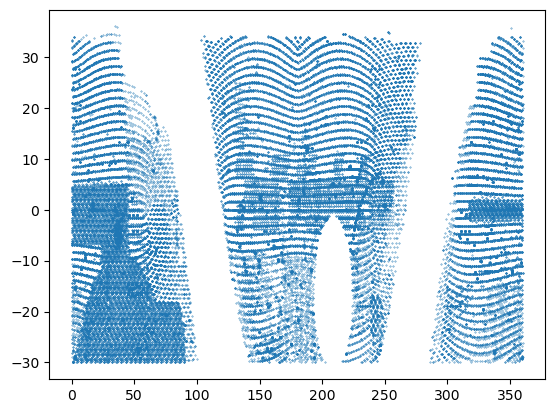

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord, get_body
import astropy.units as u
from astropy.time import Time
# import ephem


# get pointings from decam
decam_grid = pd.read_csv('/Users/tahumada/Downloads/archive_byfilter.csv')

# filter <-30 and distance to moon 20 deg

run_mjd = Time('2026-05-01')
moon = get_body('moon',run_mjd)
moon = SkyCoord(moon.ra,moon.dec)

decam_coord = SkyCoord(decam_grid.ra_center,decam_grid.dec_center,unit=(u.deg,u.deg))
idx_b = np.abs(decam_coord.galactic.b.deg)>15
idx_moon = decam_coord.separation(moon).deg > 15
idx_z = decam_grid.z == True

idx_decam_grid = (decam_grid.ra_center>0)*(decam_grid.dec_center>-30)*idx_b*idx_moon * idx_z

plt.scatter(decam_grid.ra_center[idx_decam_grid]
            ,decam_grid.dec_center[idx_decam_grid]
            ,s=0.1)

decam_grid = decam_grid[idx_decam_grid]

cond_gr = (decam_grid.r == True) * (decam_grid.g == True)
cond_dec = (decam_grid.dec_center > -35) * (decam_grid.dec_center < 10) 

# change this bit to select the hours you want
start_hour = 9
cond_1_6am = (decam_grid.ra_center > (start_hour*15)) * (decam_grid.ra_center < ((start_hour+10)*15))
# cond_2_10 = (decam_grid.ra_center > (2*15)) * (decam_grid.ra_center < (10*15))
# cond_4_10 = (decam_grid.ra_center > (4*15)) * (decam_grid.ra_center < (10*15))

# cond_decam = cond_gr * cond_dec * (cond_2_10 | cond_0_8)
cond_decam =  cond_gr * cond_dec * cond_1_6am 
decam_grid_gr = decam_grid[cond_decam]

decam_grid_gr

In [11]:
# clean the sources that are too close

import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
from astropy import units as u

# Example: df has columns 'ra' and 'dec'
# df = pd.read_csv(...)

# Convert to SkyCoord
coords = SkyCoord(ra = decam_grid_gr.ra_center.values * u.deg ,
                  dec = decam_grid_gr.dec_center.values * u.deg)



# dedup radius (e.g., 2 sq deg → r ~ 0.8 deg)
radius = 0.75 * u.deg

# Find all pairs closer than radius
idx1, idx2, sep, _ = coords.search_around_sky(coords, radius)

# Remove self-matches (i == j)
mask = idx1 < idx2
idx1 = idx1[mask]
idx2 = idx2[mask]

# Build a graph of duplicates
groups = {}
for a, b in zip(idx1, idx2):
    # union-find style grouping
    groups.setdefault(a, set()).add(b)
    groups.setdefault(b, set()).add(a)

# Pick one representative per connected component
visited = set()
keep_indices = []

for node in range(len(decam_grid_gr)):
    if node in visited:
        continue
    # BFS to find all connected neighbors
    stack = [node]
    comp = set()
    while stack:
        n = stack.pop()
        if n not in visited:
            visited.add(n)
            comp.add(n)
            stack.extend(groups.get(n, []))
    # Keep the FIRST index (or choose median/brightest etc.)
    keep_indices.append(min(comp))

# Deduplicated DataFrame
df_dedup = decam_grid_gr.iloc[keep_indices].reset_index(drop=True)

print(f"Original: {len(decam_grid_gr)} rows")
print(f"Deduped:  {len(df_dedup)} rows")


Original: 1139 rows
Deduped:  630 rows


[135.  142.5 150.  157.5 165.  172.5 180.  187.5 195.  202.5 210.  217.5
 225.  232.5 240.  247.5 255.  262.5 270.  277.5 285. ]
between RA 135.0 and 142.5 number of sources selected 15
between RA 142.5 and 150.0 number of sources selected 15
between RA 150.0 and 157.5 number of sources selected 15
between RA 157.5 and 165.0 number of sources selected 15
between RA 165.0 and 172.5 number of sources selected 15
between RA 172.5 and 180.0 number of sources selected 15
between RA 180.0 and 187.5 number of sources selected 15
between RA 187.5 and 195.0 number of sources selected 15
between RA 195.0 and 202.5 number of sources selected 15
between RA 202.5 and 210.0 number of sources selected 14
between RA 210.0 and 217.5 number of sources selected 15
between RA 217.5 and 225.0 number of sources selected 15
between RA 225.0 and 232.5 number of sources selected 15
between RA 232.5 and 240.0 number of sources selected 15
between RA 240.0 and 247.5 number of sources selected 15
between RA 247.5

Text(0, 0.5, 'dec [deg]')

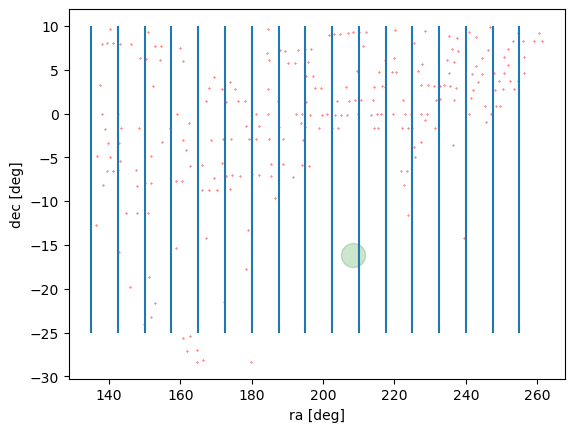

In [12]:
# AEON

# get bins of 7.5 deg (30 min)

import numpy as np

# np.arange(start, stop, step)
bins = np.arange((start_hour)*15, (start_hour+10)*15 + 7.5, 7.5)
timestamps = generate_time_list('2026-05-01 23:00:00', 30, len(bins)-1)
filts = 'grz'
print(bins)

plt.scatter(moon.ra.deg,moon.dec.deg,c='g',s=300,alpha=0.2)

# select randomly n fields, sort from high to low dec
for i in range(len(bins)-1):
    cond = (bins[i] <= df_dedup.ra_center ) * (df_dedup.ra_center <= bins[i+1])
    df_temp = df_dedup[cond]
    if len(df_temp) > 0:
        n = np.min([len(df_temp),15])
        df_temp = df_temp.sample(n=n)
        df_temp = df_temp.sort_values(by='dec_center', ascending=False)
        
        print('between RA', bins[i],'and', bins[i+1],'number of sources selected',len(df_temp))
        # print(df_temp.ra_center, df_dedup.dec_center)
        
        plt.scatter(df_temp.ra_center
                ,df_temp.dec_center
                ,s=0.1,c='r')
        
        plt.vlines(bins[i],10,-25)
        plt.xlabel('ra [deg]')
        plt.ylabel('dec [deg]')
        
        # temp_schedule = make_script_json(df_temp,filts='gr')
    
        # with open(f'./26A/May4/Ahumada_decam_{round(bins[i]/15,1)}.json', 'w') as f:
        #         json.dump(temp_schedule,f,cls=NpEncoder)
            
        np.savetxt('./May1/'+timestamps[i]+f'_{filts}.txt', np.array([df_temp.ra_center,df_temp.dec_center]).T,
                   fmt='%.6f', delimiter=' ', newline='\n', header='', footer='', comments='# ', encoding=None)

    else:
        print(timestamps[i], 'no data')

plt.xlabel('ra [deg]')
plt.ylabel('dec [deg]')
